# Home

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import nltk
import regex as re
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, Dataset
from collections import Counter

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gevabriel/indonesian-email-spam")

print("Path to dataset files:", path)

100%|██████████| 1.28M/1.28M [00:00<00:00, 97.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gevabriel/indonesian-email-spam/versions/1


In [4]:
!ls /root/.cache/kagglehub/datasets/gevabriel/indonesian-email-spam/versions/1

email_spam_indo.csv


In [25]:
import pandas as pd

df = pd.read_csv('/root/.cache/kagglehub/datasets/gevabriel/indonesian-email-spam/versions/1/email_spam_indo.csv')
df.head()

,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


In [26]:
df["Kategori"].value_counts()

,count
Kategori,
spam,1368
ham,1268


# Cleaning Dataset

In [184]:
from __future__ import annotations
import re
from dataclasses import dataclass, field
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

class EmailBodyPreprocessor:
    def __init__(self) -> None:
        self._stopwords = frozenset(StopWordRemoverFactory().get_stop_words())

    def scrubStructural(self, text: str) -> str:
        t = str(text).replace("\r\n", "\n").replace("\r", "\n").strip()
        t = re.sub(r"(?m)^[-_=]{10,}\s*$", " ", t)
        t = re.sub(r"\n{3,}", "\n\n", t)
        return t.strip()

    def normalizeNoise(self, text: str) -> str:
        t = str(text).lower()
        t = re.sub(r"https?://\S+|www\.\S+", " ", t)
        t = re.sub(r"http\S+", " ", t)
        t = re.sub(
            r"(dikeret oleh|ditahan oleh|diteruskan oleh|forwarded by|ect pada|subjek:).*",
            " ",
            t,
            flags=re.IGNORECASE,
        )
        t = re.sub(r"\b\w+\s+(com|net|org|co|id)\b", " ", t)
        t = re.sub(r"\S+@\S+", " ", t)
        t = re.sub(r"^(re|fw|fwd):[^.?!\n]*", " ", t, flags=re.IGNORECASE)
        t = re.sub(r"[^a-zA-Z\s]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t

    def removeStopwords(self, text: str) -> str:
        return " ".join(w for w in text.split() if w not in self._stopwords)

    def fullClean(self, text: str) -> str:
        t = self.scrubStructural(text)
        t = self.normalizeNoise(t)
        return self.removeStopwords(t)

@dataclass
class SpamHamDatasetCleaner:
    inputPath: str
    minCleanLength: int = 15
    dedupeOnCleanText: bool = True
    includeOriginalMessage: bool = False
    labelColumn: str = "Kategori"
    textColumn: str = "Pesan"
    allowedLabels: frozenset[str] = field(default_factory=lambda: frozenset({"spam", "ham"}))
    stats: dict[str, int] = field(default_factory=dict)
    preprocessor: EmailBodyPreprocessor = field(default_factory=EmailBodyPreprocessor)

    def normalizeLabel(self, value: object) -> str | None:
        if pd.isna(value):
            return None
        x = str(value).strip().lower()
        if x in self.allowedLabels:
            return x
        return None

    def loadCsv(self) -> pd.DataFrame:
        return pd.read_csv(self.inputPath, encoding="utf-8", on_bad_lines="skip")

    def buildCleanFrame(self, df: pd.DataFrame) -> pd.DataFrame:
        present = set(df.columns)
        if self.textColumn not in present or self.labelColumn not in present:
            raise ValueError(
                f"The CSV must include columns {self.labelColumn!r} and {self.textColumn!r}."
            )

        self.stats = {"rowsRead": len(df)}
        d = df[[self.labelColumn, self.textColumn]].copy()
        d = d.rename(columns={self.labelColumn: "label", self.textColumn: "text_raw"})

        d = d.dropna(subset=["text_raw"])
        d["text_raw"] = d["text_raw"].astype(str).str.strip()
        d = d.loc[d["text_raw"].map(len) > 0]
        self.stats["afterDropEmptyText"] = len(d)

        d["label"] = d["label"].map(self.normalizeLabel)
        d = d.dropna(subset=["label"])
        self.stats["afterValidLabel"] = len(d)

        d["clean"] = d["text_raw"].map(self.preprocessor.fullClean)

        d = d.loc[d["clean"].str.len() >= self.minCleanLength]
        self.stats["afterMinLength"] = len(d)

        if self.dedupeOnCleanText:
            d = d.drop_duplicates(subset=["clean"], keep="first")
            self.stats["afterDedupeClean"] = len(d)

        return d

    def buildOutputFrame(self, d: pd.DataFrame) -> pd.DataFrame:
        out = pd.DataFrame({"Kategori": d["label"], "Pesan": d["clean"]})
        if self.includeOriginalMessage:
            out["Pesan_asli"] = d["text_raw"].values
        return out

    def run(self) -> pd.DataFrame:
        raw = self.loadCsv()
        cleaned = self.buildCleanFrame(raw)
        out = self.buildOutputFrame(cleaned)
        return out

cleaner = SpamHamDatasetCleaner(inputPath="/root/.cache/kagglehub/datasets/gevabriel/indonesian-email-spam/versions/1/email_spam_indo.csv")
dfClean = cleaner.run()

In [185]:
dfClean

,Kategori,Pesan
0,spam,alami tak tertahankan identitas perusahaan san...
1,spam,fanny gunslinger perdagangan saham merrill muz...
2,spam,rumah rumah baru luar biasa menjadi mudah menu...
3,spam,permintaan khusus pencetakan warna informasi t...
4,spam,jangan punya uang dapatkan cd perangkat lunak ...
...,...,...
2630,ham,molly vince j kaminski am molly magee hou ect ...
2631,ham,pengingat halo semuanya vince meminta mengirim...
2633,ham,menantikan kolaborasi sangat produktif segera ...
2634,ham,persetujuan peninjau roberts jr michael a meny...


In [186]:
df = dfClean.rename(columns={
    'Pesan': 'text',
    'Kategori': 'label'
})

In [187]:
df

,label,text
0,spam,alami tak tertahankan identitas perusahaan san...
1,spam,fanny gunslinger perdagangan saham merrill muz...
2,spam,rumah rumah baru luar biasa menjadi mudah menu...
3,spam,permintaan khusus pencetakan warna informasi t...
4,spam,jangan punya uang dapatkan cd perangkat lunak ...
...,...,...
2630,ham,molly vince j kaminski am molly magee hou ect ...
2631,ham,pengingat halo semuanya vince meminta mengirim...
2633,ham,menantikan kolaborasi sangat produktif segera ...
2634,ham,persetujuan peninjau roberts jr michael a meny...


# split

In [188]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2068,)
Shape of X_test: (517,)
Shape of y_train: (2068,)
Shape of y_test: (517,)


# tokenisasi

In [39]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [189]:
def tokenize(text):
    return text.split()
train_texts = df["text"]
all_tokens = [token for text in train_texts for token in tokenize(text)]
vocab = {word: i+2 for i, word in enumerate(Counter(all_tokens))} # start from 2

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Encode the dataset

In [147]:
def encode(text, max_len=50):
  tokens = tokenize(text)
  ids = [vocab.get(t, 1) for t in tokens]
  if len(ids) < max_len:
          ids += [0] * (max_len - len(ids))
  else:
          ids = ids[:max_len]
  return ids

# Dataset Container

In [190]:
class SpamDataset(Dataset):
  def __init__(self, texts, labels):
    self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
    self.labels = torch.tensor(labels, dtype=torch.float32)
  def __len__(self):
    return len(self.texts)
  def __getitem__(self, idx):
    return self.texts[idx], self.labels[idx]

In [192]:
label_map = {"ham": 0, "spam": 1}

train_labels = y_train.map(label_map).to_numpy(dtype="float32")
test_labels  = y_test.map(label_map).to_numpy(dtype="float32")

train_texts = X_train
test_texts = X_test

In [193]:
train_ds = SpamDataset(train_texts, train_labels)
test_ds = SpamDataset(test_texts, test_labels)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32)

# Config Model

In [194]:
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
      x = self.embedding(x)
      _, (hidden, _) = self.lstm(x)
      out = self.fc(hidden[-1])
      return self.sigmoid(out).squeeze(1)

In [195]:
vocab_size = len(vocab)

model = SpamClassifier(vocab_size)

In [196]:
criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [197]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

SpamClassifier(
  (embedding): Embedding(20416, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

# Compile Model

In [207]:
import wandb

epochs = 100
train_losses = []

# Initialize wandb for logging actual training
run = wandb.init(
    entity="kartini-122450003-institut-teknologi-sumatera",
    project="my-awesome-project",
    config={
        "learning_rate": optimizer.param_groups[0]['lr'],
        "architecture": "LSTM (SpamClassifier)",
        "dataset": "Indonesian Email Spam",
        "epochs": epochs,
        "vocab_size": vocab_size,
        "embed_dim": model.embedding.embedding_dim,
        "hidden_dim": model.lstm.hidden_size,
    },
)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X, y in train_dl:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dl)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_train_loss:.4f}")

    # Log training loss to wandb
    wandb.log({"train_loss": avg_train_loss, "epoch": epoch + 1})

# Finish the wandb run after training
run.finish()

Epoch 1 | Loss: 0.0150
Epoch 2 | Loss: 0.0150
Epoch 3 | Loss: 0.0147
Epoch 4 | Loss: 0.0146
Epoch 5 | Loss: 0.0143
Epoch 6 | Loss: 0.0141
Epoch 7 | Loss: 0.0495
Epoch 8 | Loss: 0.4197
Epoch 9 | Loss: 0.0640
Epoch 10 | Loss: 0.0180
Epoch 11 | Loss: 0.0172
Epoch 12 | Loss: 0.0167
Epoch 13 | Loss: 0.0131
Epoch 14 | Loss: 0.0129
Epoch 15 | Loss: 0.0127
Epoch 16 | Loss: 0.0126
Epoch 17 | Loss: 0.0141
Epoch 18 | Loss: 0.0126
Epoch 19 | Loss: 0.0123
Epoch 20 | Loss: 0.0123
Epoch 21 | Loss: 0.0121
Epoch 22 | Loss: 0.0119
Epoch 23 | Loss: 0.0118
Epoch 24 | Loss: 0.0116
Epoch 25 | Loss: 0.0111
Epoch 26 | Loss: 0.0116
Epoch 27 | Loss: 0.0128
Epoch 28 | Loss: 0.0105
Epoch 29 | Loss: 0.0108
Epoch 30 | Loss: 0.0105
Epoch 31 | Loss: 0.0111
Epoch 32 | Loss: 0.0102
Epoch 33 | Loss: 0.0074
Epoch 34 | Loss: 0.0070
Epoch 35 | Loss: 0.0054
Epoch 36 | Loss: 0.0111
Epoch 37 | Loss: 0.0046
Epoch 38 | Loss: 0.0042
Epoch 39 | Loss: 0.0118
Epoch 40 | Loss: 0.0115
Epoch 41 | Loss: 0.0098
Epoch 42 | Loss: 0.0095
E

epoch,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,▇▆██▇▆▆▆▆▆▅▅▅▅▅▃▅▅▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▃
epoch,100
train_loss,0.00441


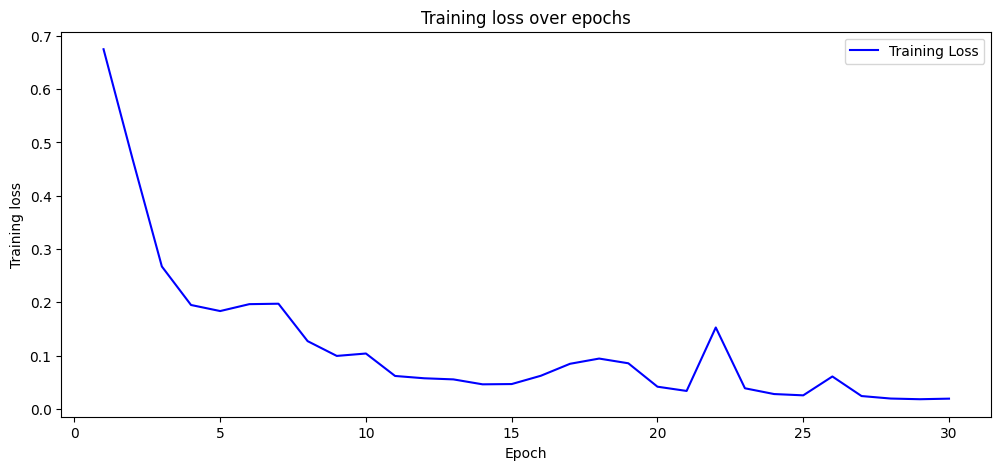

In [200]:
epochs = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))
plt.plot(epochs, train_losses, label="Training Loss", color="blue")
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.legend()
plt.show()

In [201]:
model.eval()

correct, total = 0, 0
with torch.no_grad():

    for X, y in test_dl:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        preds_cls = (preds > 0.5).float()
        correct += (preds_cls == y).sum().item()
        total += y.size(0)

print(f"Final accuracy: {correct / total:.4f}")

Final accuracy: 0.9632


### Test with custom text

In [205]:
def predict_spam(text):
    preprocessor = EmailBodyPreprocessor()
    cleaned_text = preprocessor.fullClean(text)

    encoded_text = encode(cleaned_text)
    input_tensor = torch.tensor([encoded_text], dtype=torch.long).to(device)
    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    if prediction.item() > 0.5:
        return (prediction.item(),"spam")
    else:
        return (prediction.item(),"ham")

my_text = "klaim kartu hadiah anda"
result = predict_spam(my_text)
print(f"The text '{my_text}' is classified as: {result}")

The text 'klaim kartu hadiah anda' is classified as: (0.997343122959137, 'spam')


In [203]:
dfClean[dfClean["Kategori"]=="spam"]["Pesan"][10]

'las vegas high rise boom las vegas cepat menjadi kota metropolitan utama menara bertingkat tinggi baru diharapkan dibangun strip las vegas tahun depan kondominium boom baru dimulai beli dulu fase awal harga pra konstruksi sekarang tersedia las vegas high rises termasuk trump cosmopolitan mgm turnberry icon sky bergabunglah daftar minat www verticallv dikirimkan realty one highrise pelajari lebih lanjut www verticallv comif dikecualikan surat masa mendatang balas kata hapus baris subjek'

In [204]:
WANDB="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"

<Figure size 800x600 with 0 Axes>

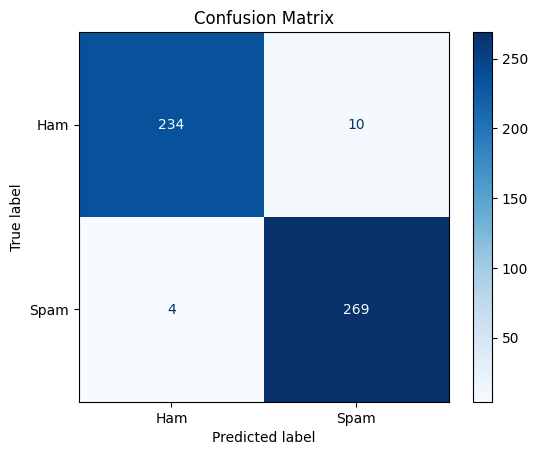


Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.96      0.97       244
        Spam       0.96      0.99      0.97       273

    accuracy                           0.97       517
   macro avg       0.97      0.97      0.97       517
weighted avg       0.97      0.97      0.97       517



In [209]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dl:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        preds_cls = (preds > 0.5).float()
        all_preds.extend(preds_cls.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Ham", "Spam"]))